In [2]:
from tifffile import imread

from matplotlib import pyplot as plt

import numpy as np

from skimage.morphology import h_maxima
from skimage.measure import regionprops

In [22]:
image = imread('/Users/abamford/Documents/ChaoLab/Imaging/Processed/20240604/Pre-patterning_D5/ACTB_well1/Max_projections/MAX_3-2_5z-1-0_561-30-100ms-1000g_488-5-50ms-200g_1_w1conf561_zproject.tif')

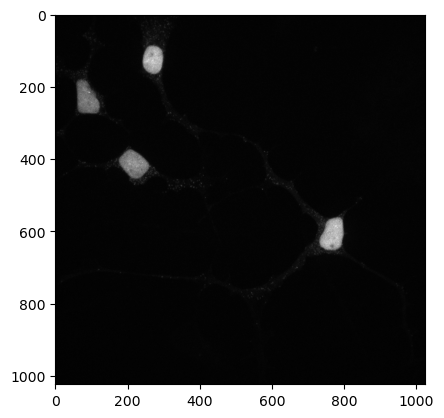

In [9]:
plt.imshow(image)

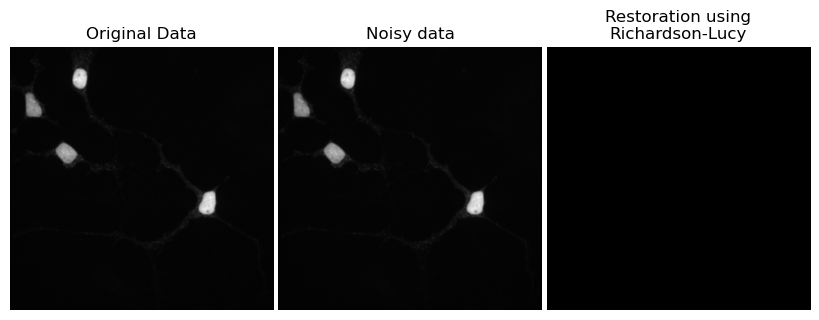

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import convolve2d as conv2

from skimage import color, data, restoration

rng = np.random.default_rng()

astro = image

psf = np.ones((5, 5)) / 25
astro = conv2(astro, psf, 'same')
# Add Noise to Image
astro_noisy = astro.copy()
astro_noisy += (rng.poisson(lam=25, size=astro.shape) - 10) / 255.0

# Restore Image using Richardson-Lucy algorithm
deconvolved_RL = restoration.richardson_lucy(astro_noisy, psf, num_iter=30)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(8, 5))
plt.gray()

for a in (ax[0], ax[1], ax[2]):
    a.axis('off')

ax[0].imshow(astro)
ax[0].set_title('Original Data')

ax[1].imshow(astro_noisy)
ax[1].set_title('Noisy data')

ax[2].imshow(deconvolved_RL, vmin=astro_noisy.min(), vmax=astro_noisy.max())
ax[2].set_title('Restoration using\nRichardson-Lucy')


fig.subplots_adjust(wspace=0.02, hspace=0.2, top=0.9, bottom=0.05, left=0, right=1)
plt.show()

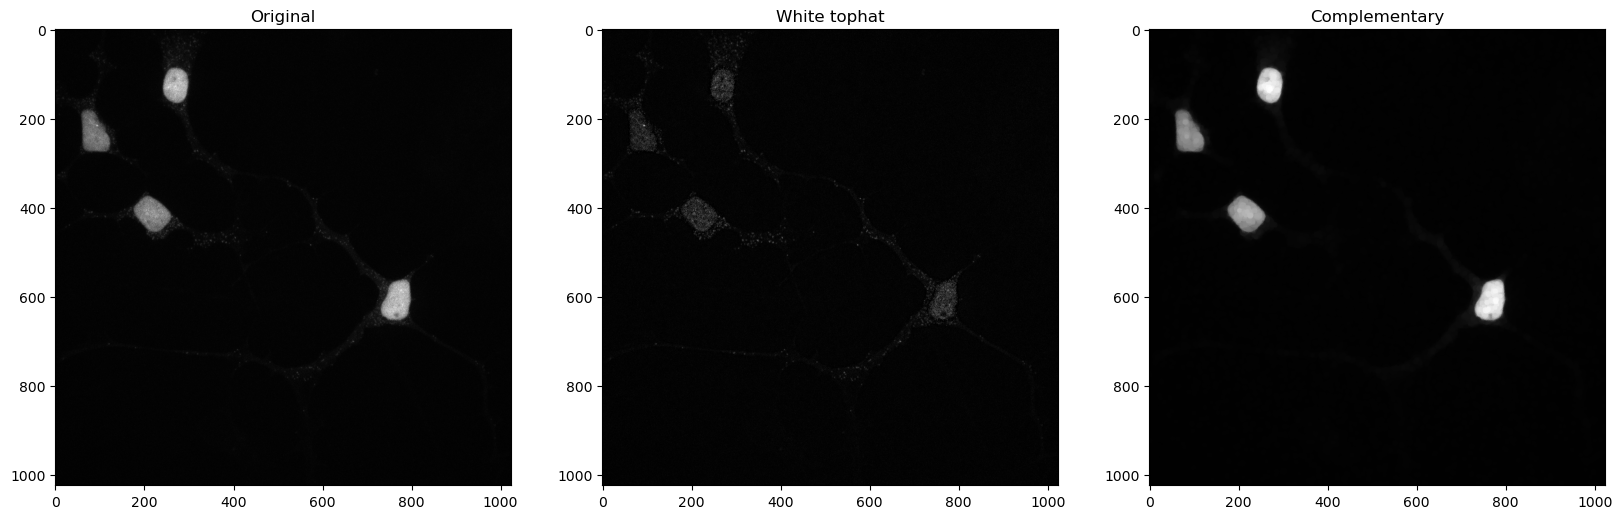

In [17]:
import matplotlib.pyplot as plt

from skimage import data
from skimage import color, morphology


footprint = morphology.disk(5)
res = morphology.white_tophat(image, footprint)

fig, ax = plt.subplots(ncols=3, figsize=(20, 8))
ax[0].set_title('Original')
ax[0].imshow(image, cmap='gray')
ax[1].set_title('White tophat')
ax[1].imshow(res, cmap='gray')
ax[2].set_title('Complementary')
ax[2].imshow(image - res, cmap='gray')

plt.show()

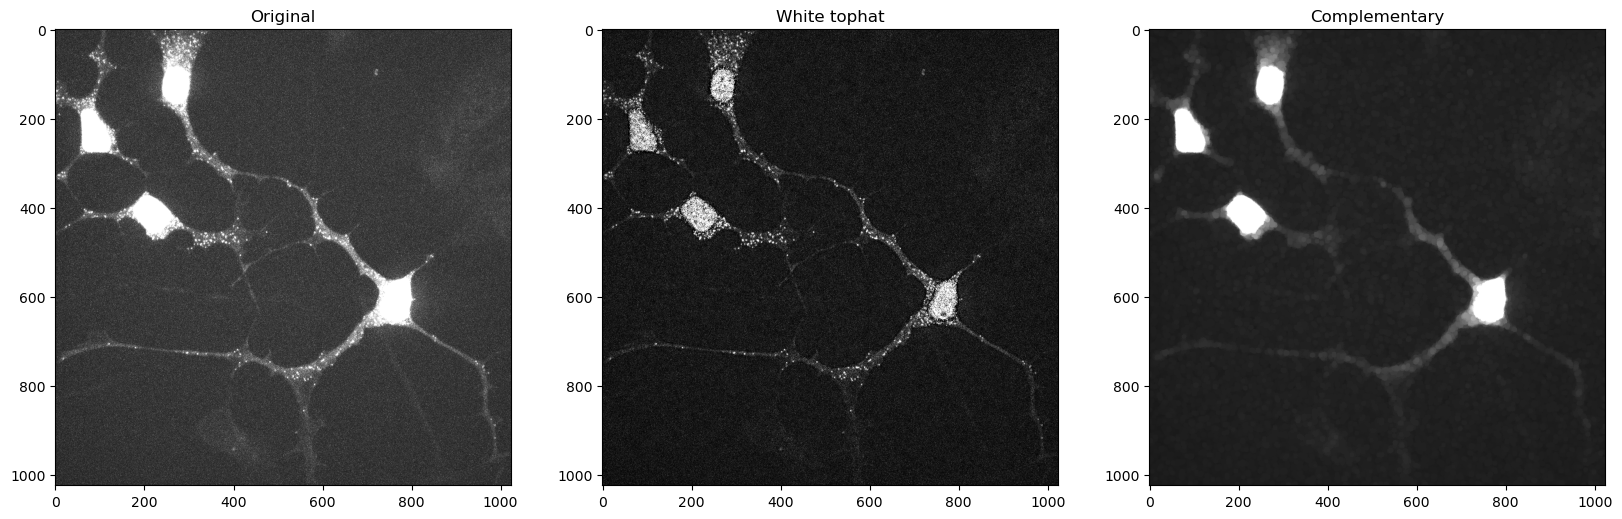

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'image' and 'res' are your image data arrays
# Adjust these values to change brightness and contrast
brightness_factor = 1.0  # Multiplies the image values
contrast_min = 0  # Minimum value for contrast adjustment
contrast_max = 5000  # Maximum value for contrast adjustment

# Apply brightness and contrast adjustments to the images
adjusted_image = np.clip(image * brightness_factor, contrast_min, contrast_max)
adjusted_res = np.clip(res * brightness_factor, contrast_min, contrast_max)
adjusted_complementary = np.clip((image - res) * brightness_factor, contrast_min, contrast_max)

# Create the figure and axes
fig, ax = plt.subplots(ncols=3, figsize=(20, 8))

# Plot the original image with adjusted brightness and contrast
ax[0].set_title('Original')
ax[0].imshow(adjusted_image, cmap='gray', vmin=contrast_min, vmax=contrast_max)

# Plot the white tophat image with adjusted brightness and contrast
ax[1].set_title('White tophat')
ax[1].imshow(adjusted_res, cmap='gray', vmin=contrast_min, vmax=contrast_max)

# Plot the complementary image with adjusted brightness and contrast
ax[2].set_title('Complementary')
ax[2].imshow(adjusted_complementary, cmap='gray', vmin=contrast_min, vmax=contrast_max)

# Show the plot
plt.show()

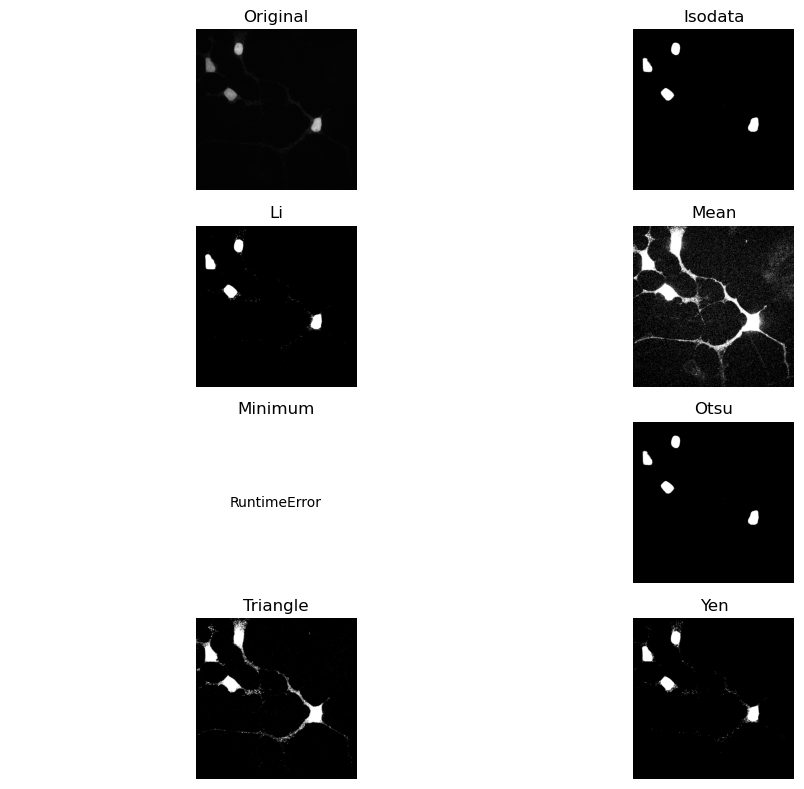

In [20]:
from skimage.filters import try_all_threshold

fig, ax = try_all_threshold(image, figsize=(10, 8), verbose=False)
plt.show()